# Explanatory Data Analysis of a Year of Online Retail Transactions

Prepared for M504 (AI and Applications) as the individual project, Gisma
University of Applied Sciences, by student GH1057991.

Notebook and supporting files: https://github.com/sonu2002/M504-AI-Applications-GH1057991


## 1. Business Context

The client is a UK-based online retailer of gifts and homeware. Its customers are mainly wholesalers, with some direct consumers, which explains the large order quantities. It holds over a year of transaction data but has never analysed it.

The analysis addresses which products earn most, which customers matter, what is returned, what sells together and when campaigns should run - none visible in the raw lines.

There are 541,909 transaction lines covering December 2010 to December 2011. Each line is one product within an order, so an order usually spans several lines. The data for this report has been taken from a transactional database originally created by Chen, Sain and Guo (2012) for their work on RFM-based Customer Segmentation and was made available through the UCI Machine Learning Repository (Dua and Graff, 2019).

## 2. Data Exploration

In [1]:
import numpy as np, pandas as pd
import itertools, collections
from matplotlib import pyplot as plt
import warnings; warnings.filterwarnings('ignore')

SRC = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
df = pd.read_excel(SRC)

def canvas(w, h):
    """every figure in this report starts here"""
    return plt.figure(figsize=(w, h)).add_subplot(111)

def show(ax, xlab='', ylab='', title=''):
    ax.set(xlabel=xlab, ylabel=ylab, title=title)
    ax.grid(axis=('x' if not ylab else 'y'), alpha=.3)
    plt.tight_layout(); plt.show()

print(f"{len(df):,} transaction lines x {df.shape[1]} fields")
# three arbitrary lines from different points in the year, transposed for readability
df.iloc[[4210, 190455, 501773]].T


541,909 transaction lines x 8 fields


,4210,190455,501773
InvoiceNo,536754,553194,578829
StockCode,22296,22212,23479
Description,HEART IVORY TRELLIS LARGE,FOUR HOOK WHITE LOVEBIRDS,WIRE EGG BASKET
Quantity,5,3,1
InvoiceDate,2010-12-02 14:09:00,2011-05-15 13:37:00,2011-11-25 14:53:00
UnitPrice,1.65,2.1,7.85
CustomerID,14449.0,16283.0,14710.0
Country,United Kingdom,United Kingdom,United Kingdom


In [2]:
# how wide is each dimension, and over what window
span = df['InvoiceDate'].agg(['min', 'max'])
print(f"window  : {span['min']:%d %b %Y} -> {span['max']:%d %b %Y}")
for col, label in [('InvoiceNo', 'orders'), ('StockCode', 'products'),
                   ('CustomerID', 'customers'), ('Country', 'markets')]:
    print(f"{label:9s}: {df[col].nunique():,}")

# spread of the two numeric fields that drive revenue
pd.DataFrame({c: {'min': df[c].min(), 'median': df[c].median(),
                  'mean': round(df[c].mean(), 2), 'max': df[c].max()}
              for c in ['Quantity', 'UnitPrice']})


window  : 01 Dec 2010 -> 09 Dec 2011
orders   : 25,900
products : 4,070
customers: 4,372
markets  : 38


,Quantity,UnitPrice
min,-80995.00,-11062.06
median,3.00,2.08
mean,9.55,4.61
max,80995.00,38970.00


In [3]:
# only the fields that actually have gaps, plus the odd values
gaps = df.isnull().sum()
for col, n in gaps[gaps > 0].items():
    print(f"blank {col:11s}: {n:,} ({n/len(df)*100:.1f}%)")
for label, mask in [('negative quantity', df['Quantity'] < 0),
                    ('zero price', df['UnitPrice'] == 0),
                    ('negative price', df['UnitPrice'] < 0)]:
    print(f"{label:18s}: {mask.sum():,} ({mask.mean()*100:.1f}%)")


blank Description: 1,454 (0.3%)
blank CustomerID : 135,080 (24.9%)
negative quantity : 10,624 (2.0%)
zero price        : 2,515 (0.5%)
negative price    : 2 (0.0%)


### 2.1 Data Exploration: Discussion

The window runs from December 2010 to December 2011, and the counts printed above show how wide each field is.

Several data-quality issues require attention. CustomerID is missing for 135,080 rows (24.9 per cent), blocking customer-level analysis there. A further 1,454 rows (0.3 per cent) lack a description, 10,624 (2.0 per cent) hold negative quantities, mostly cancellations flagged by an invoice number beginning 'C', and 2,515 (0.5 per cent) show a zero UnitPrice, probably promotional or adjustment items. Two rows carry a negative UnitPrice of -11,062.06, which are debt adjustments rather than sales.

Quantity ranges from -80,995 to +80,995: very large wholesale orders with matching cancellations. CustomerID is stored as a decimal because of the missing entries.

## 3. Data Preprocessing


In [4]:
retail = df.assign(InvoiceDate=pd.to_datetime(df['InvoiceDate']))

# customer-level questions need an attributed line
blank = int(retail['CustomerID'].isna().sum())
retail = retail[retail['CustomerID'].notna()].copy()
retail['CustomerID'] = retail['CustomerID'].astype('int64')
print(f"removed {blank:,} un-attributed lines -> {len(retail):,} remain")

# every downstream question reads these same derived fields
stamp = retail['InvoiceDate'].dt
retail['Revenue'] = retail['Quantity'].mul(retail['UnitPrice'])
retail['Year'], retail['Month'] = stamp.year, stamp.month
retail['DayOfWeek'], retail['Hour'] = stamp.dayofweek, stamp.hour
retail['IsCancelled'] = retail['InvoiceNo'].astype(str).str[0].eq('C')

# cancellations stay in retail for the returns question
sales = retail.loc[~retail['IsCancelled']]
n_cancel = int(retail['IsCancelled'].sum())
print(f"of those, {n_cancel:,} are cancellations ({n_cancel/len(retail)*100:.1f}%)")
print(f"working table: {len(retail):,} x {retail.shape[1]}, sales-only view: {len(sales):,}")


removed 135,080 un-attributed lines -> 406,829 remain


of those, 8,905 are cancellations (2.2%)
working table: 406,829 x 14, sales-only view: 397,924


### 3.1 Justification of Cleaning Decisions

The 135,080 rows with missing CustomerID values were removed, leaving 406,829 rows. This was necessary because several questions, particularly Q4, require customer-level analysis. It discards roughly a quarter of the data, and some excluded records may belong to valuable customers, so this is the main limitation in Section 5.

The 8,905 rows with InvoiceNo beginning 'C' were flagged rather than dropped, since Q5 needs them. Revenue questions read a separate sales table that excludes them.

Revenue was derived once as Quantity times UnitPrice, and Year, Month, DayOfWeek and Hour extracted once, so every question draws on the same figures.

Zero-price entries were kept: at 0.5 per cent of records they do not materially distort revenue rankings.

## 4. Explanatory Data Analysis: Business Questions

Eight questions cover products, markets, timing, customers, returns, baskets and weekly patterns. The questions are designed to include a variety of pandas techniques, including grouping, resampling, datetime operations, cumulative sums, and string manipulations.

### Q1: What are the top 10 products by total revenue?

The highest-revenue products guide stock ordering and website placement.


1. PAPER CRAFT , LITTLE BIRDIE          GBP   168,470
2. REGENCY CAKESTAND 3 TIER             GBP   142,593
3. WHITE HANGING HEART T-LIGHT HOLDER   GBP   100,448
4. JUMBO BAG RED RETROSPOT              GBP    85,221
5. MEDIUM CERAMIC TOP STORAGE JAR       GBP    81,417


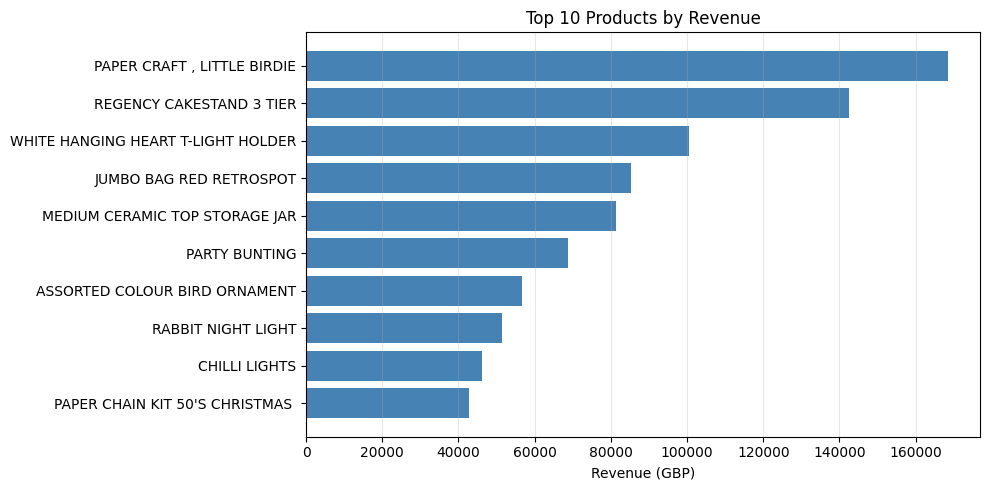

In [5]:
# genuine stock lines carry a 5-digit code; postage and adjustments do not
code5 = retail['StockCode'].astype(str).str.match(r'^\d{5}')
goods = sales.loc[code5.reindex(sales.index, fill_value=False)]
best = goods.groupby('Description')['Revenue'].sum().nlargest(10)
for rank, (name, rev) in enumerate(best.head(5).items(), 1):
    print(f"{rank}. {name.strip():36s} GBP {rev:>9,.0f}")

ax = canvas(10, 5)
ax.barh(best.index[::-1], best.values[::-1], color='steelblue')
show(ax, 'Revenue (GBP)', '', 'Top 10 Products by Revenue')


The chart shows that PAPER CRAFT, LITTLE BIRDIE generated the highest revenue at GBP 168,470. Revenue then falls sharply among the remaining products, showing a long-tail pattern in which a few products generate most of the revenue while the long tail contributes progressively smaller amounts. Only five-digit StockCodes were ranked, which removes postage and adjustment charges from the comparison. The retailer should keep the leading products reliably in stock and give them prominent placement on the website.

### Q2: Is the largest market also the most valuable one per customer?

Revenue alone hides how much each market is worth per account, which is what decides where sales effort should go.


UK takes 82.0% of turnover from 3,921 accounts, worth GBP 1,864 each

richest accounts by market (5+ customers):
  Netherlands      9 accounts  GBP   31,716 each
  Australia        9 accounts  GBP   15,391 each
  Sweden           8 accounts  GBP    4,797 each
  Japan            8 accounts  GBP    4,677 each
  Norway          10 accounts  GBP    3,617 each
  Switzerland     21 accounts  GBP    2,688 each


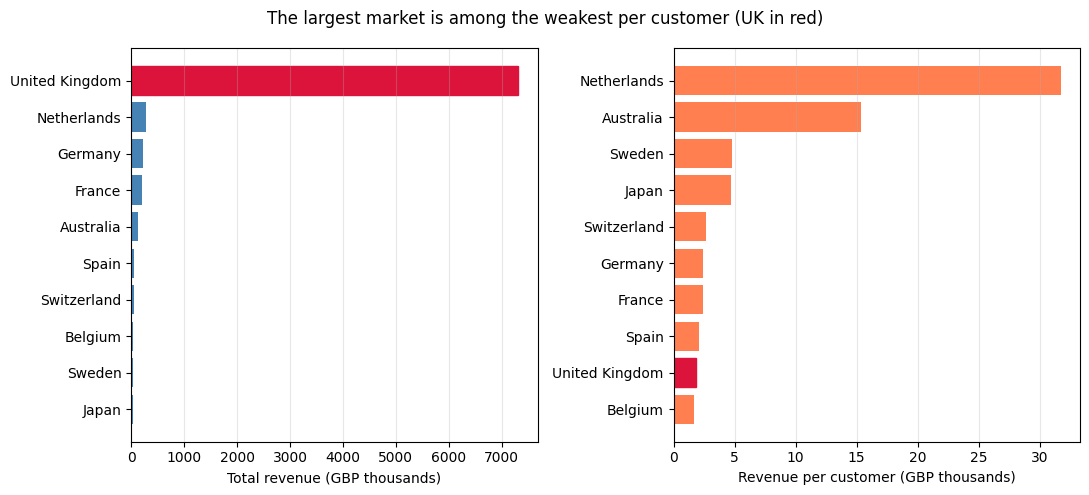

In [6]:
# does market size translate into value per account
mkt = sales.pivot_table(index='Country', values=['Revenue', 'CustomerID'],
                        aggfunc={'Revenue': 'sum', 'CustomerID': 'nunique'})
mkt.columns = ['accounts', 'turnover']
mkt['each'] = mkt['turnover'].div(mkt['accounts'])
uk = mkt.loc['United Kingdom']
print(f"UK takes {uk['turnover']/mkt['turnover'].sum()*100:.1f}% of turnover from "
      f"{uk['accounts']:,.0f} accounts, worth GBP {uk['each']:,.0f} each\n")
print("richest accounts by market (5+ customers):")
big = mkt[mkt['accounts'].ge(5)]
for name, r in big.nlargest(6, 'each').iterrows():
    print(f"  {name:14s} {r['accounts']:>3.0f} accounts  GBP {r['each']:>8,.0f} each")

sub = big.nlargest(10, 'turnover')
panel = plt.figure(figsize=(11, 5))
for pos, (col, lab, shade) in enumerate([
        ('turnover', 'Total revenue (GBP thousands)', 'steelblue'),
        ('each', 'Revenue per customer (GBP thousands)', 'coral')], 1):
    ranked = sub.sort_values(col)
    ax = panel.add_subplot(1, 2, pos)
    drawn = ax.barh(ranked.index, ranked[col].div(1000), color=shade)
    drawn[ranked.index.get_loc('United Kingdom')].set_color('crimson')
    ax.set(xlabel=lab)
    ax.grid(axis='x', alpha=.3)
panel.suptitle('The largest market is among the weakest per customer (UK in red)')
plt.tight_layout(); plt.show()


The UK has the largest volume (82 per cent of revenue, 3,921 customers) but the lowest per-customer value (GBP 1,864) versus the Netherlands (GBP 31,716, 17x). Markets with fewer than five customers were excluded as too small to compare. However, only 9 accounts exist in the Netherlands, so a single large wholesaler could be skewing the average. Focus acquisition on proven high-value markets rather than new ones.


### Q3: What time of day sees the most ordering activity?

The best time to advertise or email is just before customers normally place orders.

busiest slot is 12:00 carrying 3,129 orders


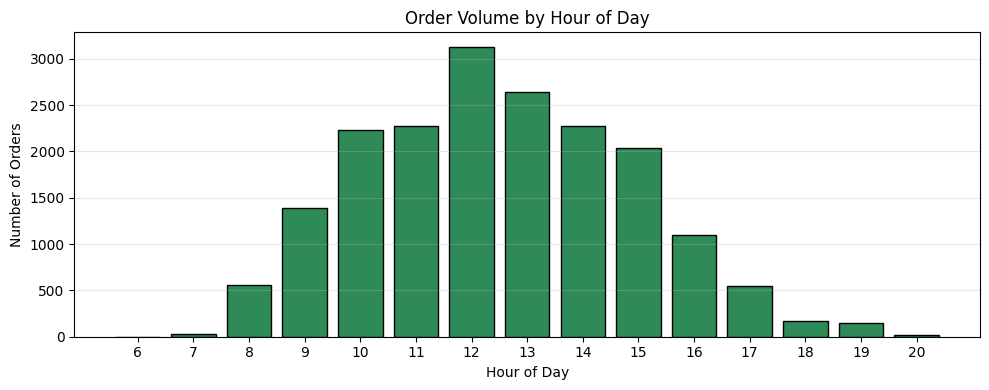

In [7]:
# count invoices rather than line items
hourly = sales.drop_duplicates('InvoiceNo')['Hour'].value_counts().sort_index()
print(f"busiest slot is {hourly.idxmax()}:00 carrying {hourly.max():,} orders")

ax = canvas(10, 4)
ax.bar([str(h) for h in hourly.index], hourly.values,
       color='seagreen', edgecolor='black')
show(ax, 'Hour of Day', 'Number of Orders', 'Order Volume by Hour of Day')


Order activity is concentrated between roughly 10:00 and 15:00, peaking at 12:00 with 3,129 orders. This business-hours pattern is typical of wholesale buyers. Emails and adverts should therefore arrive in the mid-morning, around 9:00 to 10:00, just before the ordering peak.

### Q4: Does the Pareto pattern hold - does a small share of customers drive most of the revenue?

This decides whether the client should invest in dedicated account management for a small set of large customers.

4,339 accounts placed at least one order
1,132 of them (26.1%) account for four fifths of turnover
the five largest alone carry 11.7%


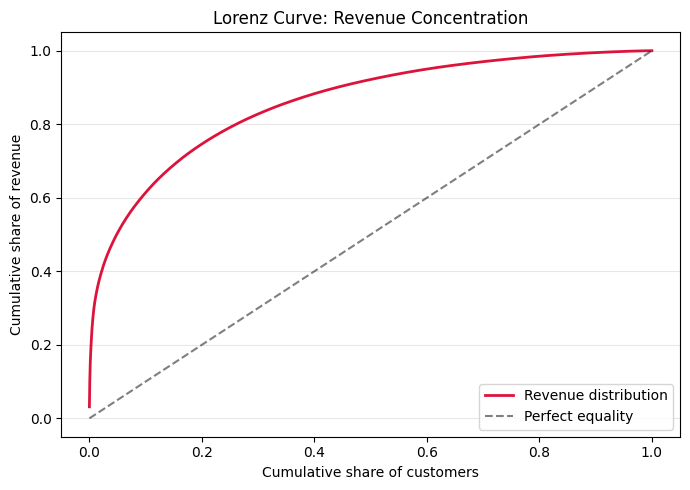

In [8]:
# Lorenz curve of cumulative revenue share
spend = sales.groupby('CustomerID')['Revenue'].sum().sort_values()[::-1]
cum = spend.cumsum().div(spend.sum())
core = int(cum.le(0.80).sum())
print(f"{len(spend):,} accounts placed at least one order")
print(f"{core:,} of them ({core/len(cum)*100:.1f}%) account for four fifths of turnover")
print(f"the five largest alone carry {spend.head(5).sum()/spend.sum()*100:.1f}%")

share = np.linspace(0, 1, len(cum))
ax = canvas(7, 5)
ax.plot(share, cum.values, color='crimson', lw=2, label='Revenue distribution')
ax.plot(share, share, color='black', ls='--', alpha=.5, label='Perfect equality')
ax.legend(loc=4)
show(ax, 'Cumulative share of customers', 'Cumulative share of revenue',
     'Lorenz Curve: Revenue Concentration')


The Lorenz curve shows that 26.1 per cent of purchasing customers (1,132 of 4,339) generate 80 per cent of revenue, broadly consistent with the Pareto principle (the 80-20 rule), and the top five alone account for 11.7 per cent. Revenue therefore depends heavily on a minority of accounts, which deserve dedicated account management; losing one of the largest customers would be costly.

### Q5: Which products have the highest return rates, and should the client be concerned?

High returns can signal quality or listing problems, and each returned order erases revenue.

highest return rates, lines selling 100+ units:
  118.5%  ROTATING SILVER ANGELS T-LIGHT HLDR
  100.0%  PAPER CRAFT , LITTLE BIRDIE
   95.6%  MEDIUM CERAMIC TOP STORAGE JAR
   95.1%  SET OF 3 BABUSHKA STACKING TINS
   83.1%  PANTRY CHOPPING BOARD


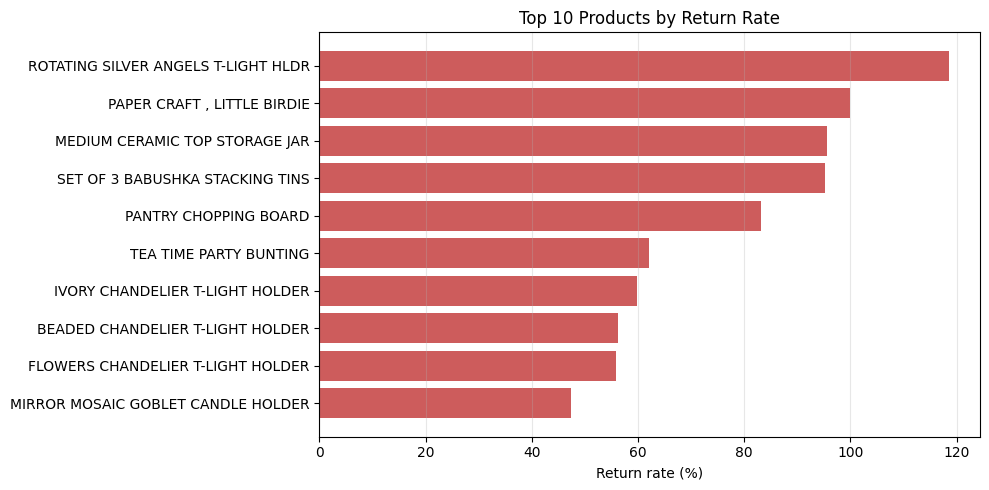

In [9]:
# units sent back as a share of units sold
shipped = goods.pivot_table(index='Description', values='Quantity', aggfunc='sum')['Quantity']
back = retail.loc[retail['IsCancelled'] & code5]
returned = back.groupby('Description')['Quantity'].sum().abs()
popular = shipped[shipped.ge(100)]
worst = returned.reindex(popular.index).fillna(0).div(popular).mul(100).nlargest(10)
print("highest return rates, lines selling 100+ units:")
for name, rate in worst.head(5).items():
    print(f"  {rate:5.1f}%  {name.strip()}")

ax = canvas(10, 5)
ax.barh(worst.index[::-1], worst.values[::-1], color='indianred')
show(ax, 'Return rate (%)', '', 'Top 10 Products by Return Rate')


The return rates are highest for ROTATING SILVER ANGELS T-LIGHT HLDR, at approximately 118.5 per cent, followed by PAPER CRAFT LITTLE BIRDIE at about 100 per cent and MEDIUM CERAMIC TOP STORAGE JAR at 95.6 per cent. A rate can exceed 100 per cent because returns were matched to same-year sales, so items sold earlier appear among this year's returns: a data-matching limitation, not impossible behaviour. Only items selling at least 100 units were ranked, so that a handful of sales cannot produce a misleading rate. Products above roughly 50 per cent should be reviewed for potential quality issues, listing accuracy, or ordering errors. However, the data does not record the reason for each return, so the cause cannot be confirmed.

### Q6: Which products are most often bought together in the same order?

Recurring pairs show where bundles and cross-sell placements will work.


6,592 multi-item baskets examined; strongest pairings:
  seen 106 times -> GREEN REGENCY TEACUP AND SAUCER / ROSES REGENCY TEACUP AND SAUCER
  seen  94 times -> GREEN REGENCY TEACUP AND SAUCER / PINK REGENCY TEACUP AND SAUCER
  seen  93 times -> ALARM CLOCK BAKELIKE GREEN / ALARM CLOCK BAKELIKE RED


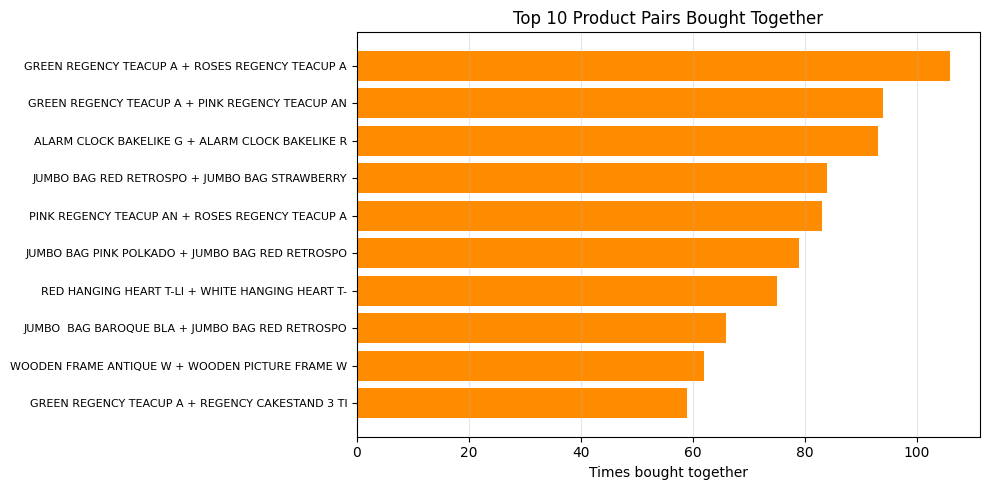

In [10]:
# how often two products share an invoice
lists = goods.groupby('InvoiceNo')['Description'].agg(lambda x: sorted(set(x)))
baskets = [b for b in lists if 2 <= len(b) <= 12]
tally = collections.Counter()
for chosen in baskets:
    tally.update(itertools.combinations(chosen, 2))
top = pd.Series(dict(tally.most_common(10)))
print(f"{len(baskets):,} multi-item baskets examined; strongest pairings:")
for (first, second), n in top.head(3).items():
    print(f"  seen {n:>3} times -> {first.strip()} / {second.strip()}")
top.index = [f"{first[:22]} + {second[:22]}" for first, second in top.index]

ax = canvas(10, 5)
ax.barh(top.index[::-1], top.values[::-1], color='darkorange')
ax.tick_params(axis='y', labelsize=8)
show(ax, 'Times bought together', '', 'Top 10 Product Pairs Bought Together')


Across 6,592 baskets, seven of the top ten pairs are the same product in two colourways rather than two different products: three teacup pairings, three jumbo bags and the two alarm clocks all follow that shape. Of the remaining three, two pair near-identical lines - the hanging-heart holders and the wooden frames - leaving only the teacup and cakestand pairing as a genuine cross-sell.

Customers are buying colour sets rather than complementary products, which points to bundle offers, "complete the set" messaging and holding all colours in one stocking location.


### Q7: What is the average order value and how many items are bought per order?

Typical order value sets thresholds for free shipping or volume discounts that can increase basket size.

peak trading month Nov 2011, GBP 1,161,817
18,536 orders placed in total
typical order: GBP 303.02 median against GBP 480.76 mean
units per order averages 279.5


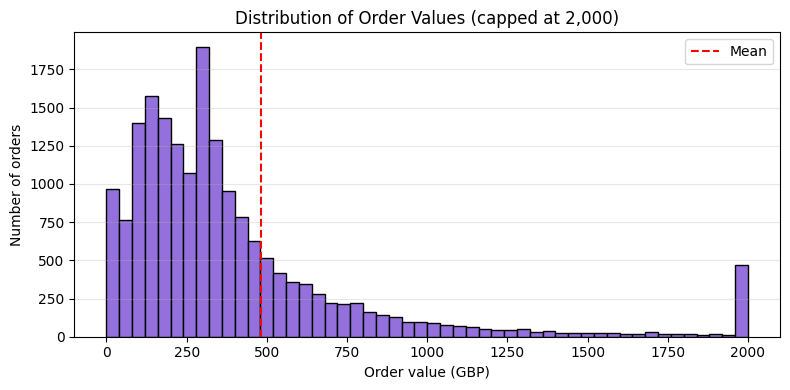

In [11]:
# roll line items up to one row per invoice
orders = sales.pivot_table(index='InvoiceNo', values=['Revenue', 'Quantity'], aggfunc='sum')
peak = sales.resample('ME', on='InvoiceDate')['Revenue'].sum()
print(f"peak trading month {peak.idxmax():%b %Y}, GBP {peak.max():,.0f}")
print(f"{len(orders):,} orders placed in total")
print(f"typical order: GBP {orders['Revenue'].median():,.2f} median "
      f"against GBP {orders['Revenue'].mean():,.2f} mean")
print(f"units per order averages {orders['Quantity'].mean():.1f}")

ax = canvas(8, 4)
ax.hist(orders['Revenue'].clip(upper=2000), bins=50,
        color='mediumpurple', edgecolor='black')
ax.axvline(orders['Revenue'].mean(), color='red', ls='--', label='Mean')
ax.legend(loc='upper right')
show(ax, 'Order value (GBP)', 'Number of orders',
     'Distribution of Order Values (capped at 2,000)')


The mean order value is GBP 480.76, while the median order value is GBP 303.02. The gap between them shows a few very large wholesale orders pulling the mean up, making the median the more representative measure of a typical order. The mean of 279.5 items per order confirms a wholesale customer base. The histogram is capped at GBP 2,000 so the bulk of orders stays readable, with larger orders collected in the final bar. Setting free-shipping thresholds slightly above the typical order value could push customers towards larger orders.

### Q8: Do weekends perform differently from weekdays?

Weekend patterns affect staffing decisions and whether weekend consumer promotions are worth testing.

Weekday  255 trading days -> 64.2 orders and GBP 31,839 a day
Weekend   50 trading days -> 43.4 orders and GBP 15,850 a day


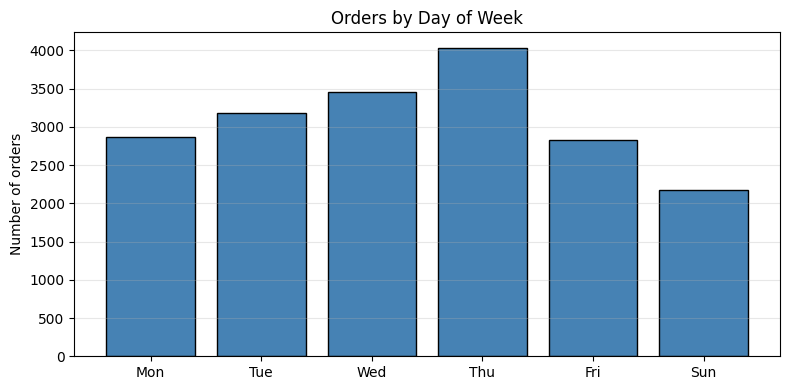

In [12]:
# normalise by how many of each day were traded
cal = pd.Index(retail['InvoiceDate'].dt.normalize().unique())
we_days = int(cal.dayofweek.isin([5, 6]).sum())
weekend = sales['DayOfWeek'].isin([5, 6])
for label, keep, nd in [('Weekday', ~weekend, len(cal) - we_days),
                        ('Weekend', weekend, we_days)]:
    part = sales[keep]
    print(f"{label:8s} {nd:>3} trading days -> {part['InvoiceNo'].nunique()/nd:.1f} orders "
          f"and GBP {part['Revenue'].sum()/nd:,.0f} a day")

short = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily = sales.drop_duplicates('InvoiceNo')['DayOfWeek'].value_counts().sort_index()
ax = canvas(8, 4)   # labels come from the index: this data has no Saturday trading
ax.bar([short[d] for d in daily.index], daily.values,
       color='steelblue', edgecolor='black')
show(ax, '', 'Number of orders', 'Orders by Day of Week')


Activity is far higher on weekdays (64.2 orders and GBP 31,839 per day) than at weekends (43.4 orders and GBP 15,850 per day), consistent with the business-hours pattern identified in Q3. The chart also shows no Saturday trading at all, so weekend activity here means Sunday only. Staffing and customer support could therefore be reduced at weekends. Weekend-only promotions remain worth testing as a low-cost way to reach the smaller retail segment.

## 5. Discussion, Limitations and Recommendations

Four questions show the range of techniques used. Resampling put the strongest month, November, at roughly GBP 1.16 million. A cumulative sum returned 26.1 per cent of customers behind 80 per cent of revenue. String operations isolated 8,905 cancellations by invoice prefix. Datetime features placed the ordering peak at 12 noon. Data quality concerns, especially missing customer IDs and return matching, were addressed openly.

The key findings share a single common thread: the business is concentrated across three independent axes, each a form of structural vulnerability. A small group of best products, one dominant market and a few high value customers hold a disproportionate share of turnover - with a stock out on a key product, a downturn in the UK market or the churn of a high value customer, the business would be vulnerable to a significant loss of turnover. Demand concentrates in working hours and weekdays, peaking in November, as expected in wholesale. This is further confirmed by the difference between the mean and median order value, with a few large wholesale orders skewing the average order value upwards. High returns on some products mark a further area for attention.

These results carry limitations. Analysing only identified customers removed 24.9 per cent of rows. No cost or margin data is held, so high revenue cannot be read as high profit. Only one year is covered, and customer demographics extend no further than country. Return reasons are also not recorded, and returns were matched against same-year sales, so items sold earlier may appear among current returns.

The business should protect key accounts with dedicated account management and prepare for the Q4 demand rise from October, ahead of the November peak. Products returning above 50 per cent should be reviewed for quality, listing and ordering problems. Mid-morning weekday email campaigns should be tested against the observed demand peak. Weekend promotions and European expansion offer low-risk experiments to test the retail and geographic opportunities.

## 6. References

Chen, D., Sain, S.L. and Guo, K. (2012) 'Data mining for the online retail industry: a case study of RFM model-based customer segmentation using data mining', Journal of Database Marketing and Customer Strategy Management, 19(3), pp. 197-208.

Dua, D. and Graff, C. (2019) UCI Machine Learning Repository: Online Retail Dataset. Irvine, CA: University of California. Available at: https://archive.ics.uci.edu/ml/datasets/Online+Retail (Accessed: 30 August 2026).